In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
import pandas as pd

SEED = 123
np.random.seed(SEED)

In [48]:

distance_matrix = np.load('../duomenys/dist_mat.npy')
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
label_names = {i: name for i, name in enumerate(unique_labels)}

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)


DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)

In [49]:
# aibiu padalijimas  (70/30)
idx_train, idx_test = train_test_split(
    np.arange(n_samples), test_size=0.3, random_state=SEED, stratify=labels_encoded
)

X_train_tsne, X_test_tsne = embedding[idx_train], embedding[idx_test]
y_train_tsne, y_test_tsne = labels_encoded[idx_train], labels_encoded[idx_test]

X_train_orig, X_test_orig = original_flat[idx_train], original_flat[idx_test]
y_train_orig, y_test_orig = labels_encoded[idx_train], labels_encoded[idx_test]



In [50]:

# KNN originalioje dimensijoje;
# normavimas + mokymas + metrikos

def run_knn(X_train, X_test, y_train, y_test, label_names, title_prefix, k=5):
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)

    classes = np.unique(np.concatenate([y_train, y_test]))
    cm = confusion_matrix(y_test, y_pred, labels=classes)

    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm,
                         index=[label_names[c] for c in classes],
                         columns=[label_names[c] for c in classes])
    print(cm_df.to_string())

    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)

    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n

    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in classes]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")

    return clf, X_train_sc, X_test_sc, scaler



In [51]:
# 2D skiriamieji pavirsiai

def plot_decision_boundary(clf, X_train_sc, X_test_sc,
                           y_train, y_test, label_names,
                           title, ax, step=0.3):
    unique_classes = np.unique(np.concatenate([y_train, y_test]))

    x_min = min(X_train_sc[:,0].min(), X_test_sc[:,0].min()) - 1
    x_max = max(X_train_sc[:,0].max(), X_test_sc[:,0].max()) + 1
    y_min = min(X_train_sc[:,1].min(), X_test_sc[:,1].min()) - 1
    y_max = max(X_train_sc[:,1].max(), X_test_sc[:,1].max()) + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_train == cls
        ax.scatter(X_train_sc[mask, 0], X_train_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")



   k |  F1 vidurkis |   F1 std | Acc vidurkis |  Acc std
-----------------------------------------------------------------
   3 |       0.7320 |   0.0471 |       0.7293 |   0.0466
   4 |       0.7179 |   0.0608 |       0.7160 |   0.0617
   5 |       0.7106 |   0.0753 |       0.7080 |   0.0734
   7 |       0.6830 |   0.0718 |       0.6787 |   0.0709
  11 |       0.6371 |   0.0630 |       0.6360 |   0.0631
  15 |       0.6244 |   0.0637 |       0.6240 |   0.0625
  21 |       0.6277 |   0.0697 |       0.6280 |   0.0665
  30 |       0.6032 |   0.0703 |       0.6053 |   0.0651

Geriausias k = 3  (F1 = 0.7320 ± 0.0471)


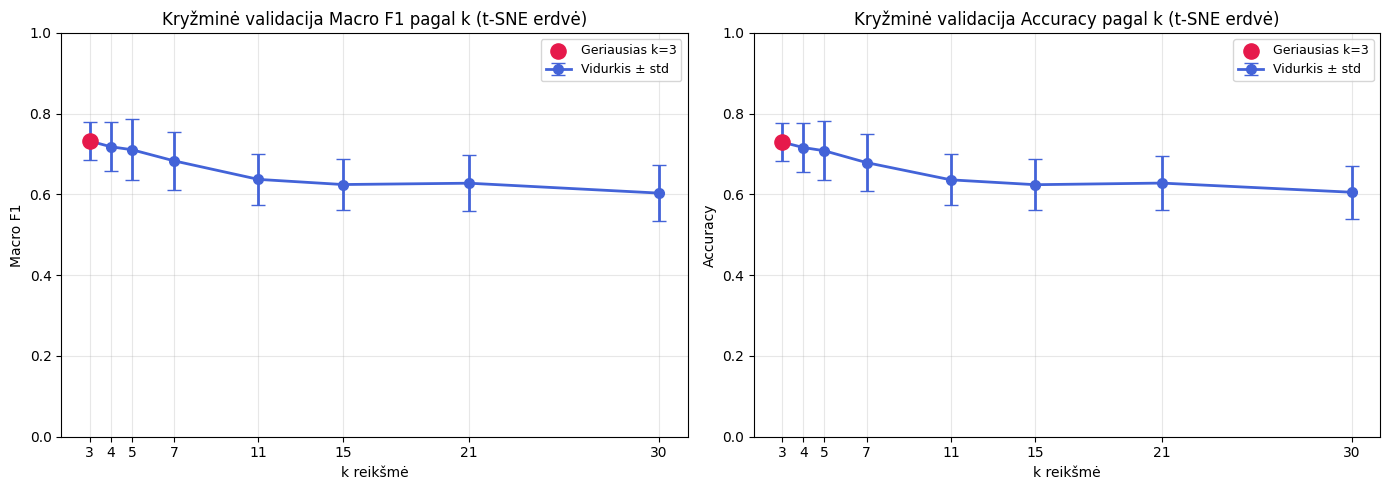

In [52]:

K_LIST = [3, 4, 5, 7, 11, 15, 21, 30]
N_FOLDS = 10  # 10-fold 

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_results = {}
for k in K_LIST:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_validate(
        pipe, embedding, labels_encoded, cv=cv,  # visas duomenų rinkinys
        scoring={"f1": "f1_macro", "acc": "accuracy"},
        return_train_score=False
    )
    cv_results[k] = {
        "f1_mean":  scores["test_f1"].mean(),
        "f1_std":   scores["test_f1"].std(),
        "acc_mean": scores["test_acc"].mean(),
        "acc_std":  scores["test_acc"].std(),
        "f1_folds": scores["test_f1"],
        "acc_folds": scores["test_acc"],
    }

# ── Lentelė
print(f"{'k':>4} | {'F1 vidurkis':>12} | {'F1 std':>8} | {'Acc vidurkis':>12} | {'Acc std':>8}")
print("-"*65)
for k in K_LIST:
    r = cv_results[k]
    print(f"{k:>4} | {r['f1_mean']:>12.4f} | {r['f1_std']:>8.4f} "
          f"| {r['acc_mean']:>12.4f} | {r['acc_std']:>8.4f}")

best_k = max(K_LIST, key=lambda k: cv_results[k]["f1_mean"])
print(f"\nGeriausias k = {best_k}  "
      f"(F1 = {cv_results[best_k]['f1_mean']:.4f} ± {cv_results[best_k]['f1_std']:.4f})")

# ── Vizualizacija
fig_cv, axes_cv = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in zip(axes_cv, ["f1", "acc"], ["Macro F1", "Accuracy"]):
    means = [cv_results[k][f"{metric}_mean"] for k in K_LIST]
    stds  = [cv_results[k][f"{metric}_std"]  for k in K_LIST]

    ax.errorbar(K_LIST, means, yerr=stds, fmt='o-', capsize=5,
                color='#4363D8', linewidth=2, markersize=7, label='Vidurkis ± std')

    # Pažymėti geriausią k
    best_val = cv_results[best_k][f"{metric}_mean"]
    ax.scatter([best_k], [cv_results[best_k][f"{metric}_mean"]],
               color='#E6194B', s=120, zorder=5, label=f'Geriausias k={best_k}')

    ax.set_xlabel("k reikšmė")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Kryžminė validacija {ylabel} pagal k (t-SNE erdvė)")
    ax.set_xticks(K_LIST)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('./plots/knn_cv.svg', format='svg')
plt.show()


In [53]:
# KNN klasifikavimas 2D

print("\nKNN klasifikavimas sumažintoje 2D dimensijoje (t-SNE)")
clf_tsne, Xtr_tsne_sc, Xte_tsne_sc, sc_tsne = run_knn(
    X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne,
    label_names, title_prefix="t-SNE erdvė", k=3
)


KNN klasifikavimas sumažintoje 2D dimensijoje (t-SNE)
Klasifikavimo lentele (true/pred)
           Cargo  Fishing  Passenger  Pilot  Tanker
Cargo         26        6          2      1      10
Fishing        9       28          1      2       5
Passenger      8        2         28      2       5
Pilot          6        3          2     34       0
Tanker        10        3          2      1      29

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.4407  0.5778  0.5000
Fishing       0.6667  0.6222  0.6437
Passenger     0.8000  0.6222  0.7000
Pilot         0.8500  0.7556  0.8000
Tanker        0.5918  0.6444  0.6170

Accuracy      : 0.6444
Macro precision : 0.6698
Macro recall    : 0.6444
Macro F1        : 0.6521


In [54]:
# KNN klasifikavimas originaliems duomenims
print("\nKNN klasifikavimas originaliems duomenims")
clf_orig, Xtr_orig_sc, Xte_orig_sc, sc_orig = run_knn(
    X_train_orig, X_test_orig, y_train_orig, y_test_orig,
    label_names, title_prefix="Originalūs duomenys", k=3
)



KNN klasifikavimas originaliems duomenims
Klasifikavimo lentele (true/pred)
           Cargo  Fishing  Passenger  Pilot  Tanker
Cargo         39        5          1      0       0
Fishing        7       35          0      0       3
Passenger      5        6         29      2       3
Pilot          5        3          9     27       1
Tanker        10        6          1      1      27

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.5909  0.8667  0.7027
Fishing       0.6364  0.7778  0.7000
Passenger     0.7250  0.6444  0.6824
Pilot         0.9000  0.6000  0.7200
Tanker        0.7941  0.6000  0.6835

Accuracy      : 0.6978
Macro precision : 0.7293
Macro recall    : 0.6978
Macro F1        : 0.6977


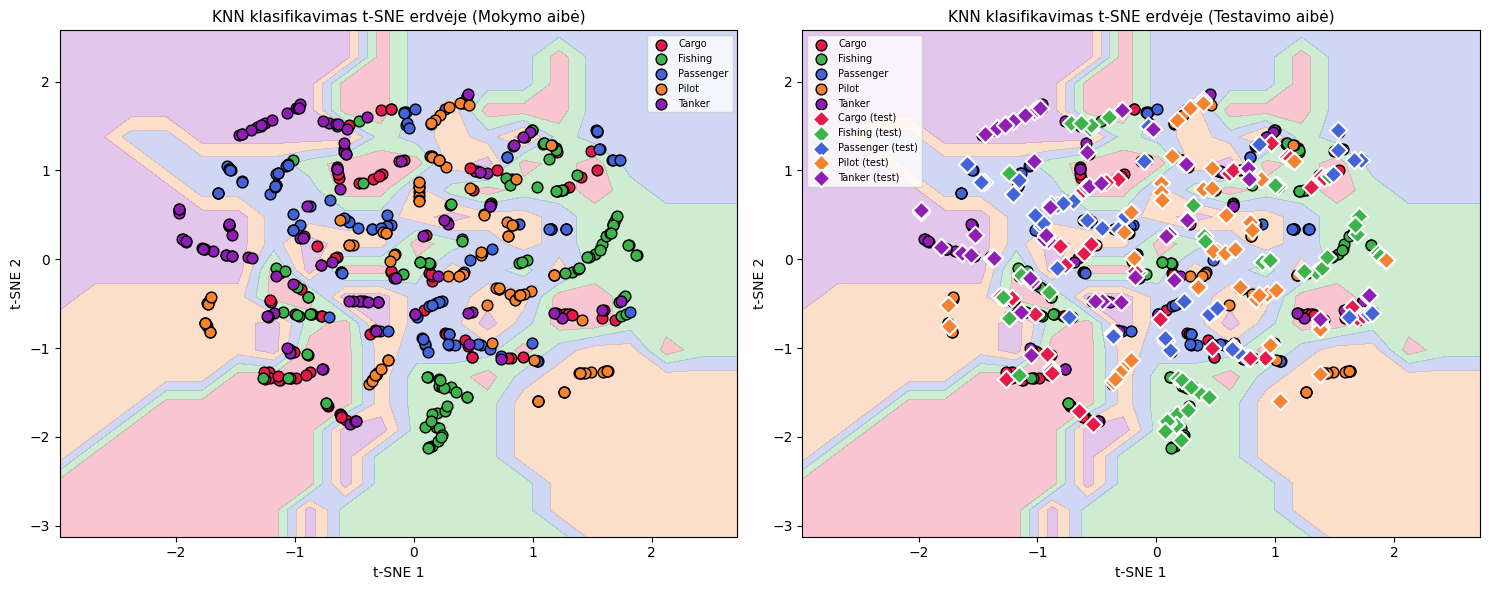

In [55]:

# sumazintoje erdveje (tsne 2d) mokymosi ir testavimo aibiu rezultatai su skiriamuoju pavirsiu

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_decision_boundary(clf_tsne, Xtr_tsne_sc, Xte_tsne_sc,
                       y_train_tsne, y_test_tsne, label_names,
                       title="KNN klasifikavimas t-SNE erdvėje (Mokymo aibė)", ax=axes[0])


plot_decision_boundary(clf_tsne, Xtr_tsne_sc, Xte_tsne_sc,
                       y_train_tsne, y_test_tsne, label_names,
                       title="KNN klasifikavimas t-SNE erdvėje (Testavimo aibė)", ax=axes[1])

for cls in np.unique(y_test_tsne):
    mask = y_test_tsne == cls
    axes[1].scatter(Xte_tsne_sc[mask, 0], Xte_tsne_sc[mask, 1],
                    c=class_colors[cls], edgecolors='white',
                    linewidths=1.5, s=80, marker='D', zorder=4,
                    label=f"{label_names[cls]} (test)")

axes[1].legend(fontsize=7, loc="best")
plt.tight_layout()
# plt.savefig('./plots/knn_2d_boundary.svg', format="svg")
plt.show()

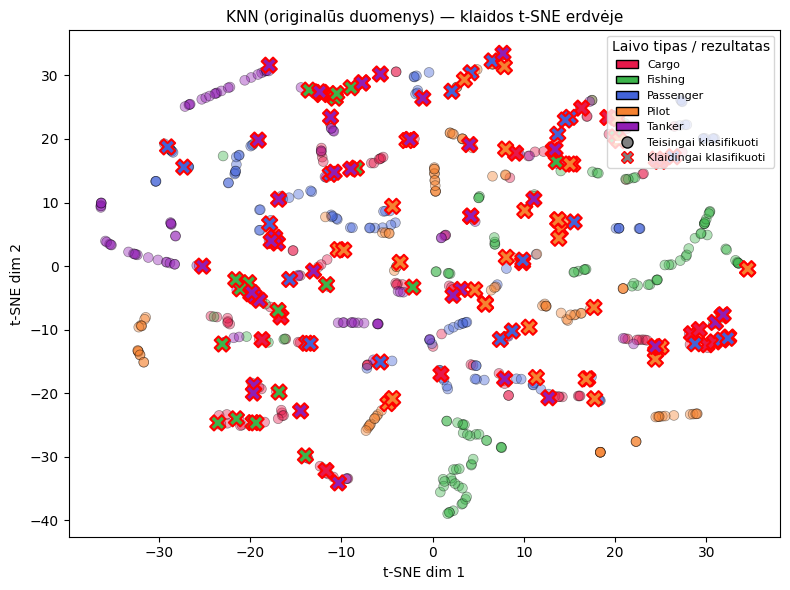

In [56]:

# originaliu duomenu klaidos t-SNE 

fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred_full = clf_orig.predict(sc_orig.transform(original_flat))
correct = y_pred_full == labels_encoded

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(embedding[correct, 0], embedding[correct, 1],
            c=[class_colors[c] for c in labels_encoded[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(embedding[~correct, 0], embedding[~correct, 1],
            c=[class_colors[c] for c in labels_encoded[~correct]],
            s=120, edgecolors='red', linewidths=1.5, marker='X', alpha=1.0, zorder=3)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
class_patches = [Patch(facecolor=class_colors[i], edgecolor='k',
                       label=label_names[i]) for i in unique_cls]
marker_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='k', markersize=8, label='Teisingai klasifikuoti'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='gray',
           markeredgecolor='red', markersize=8, label='Klaidingai klasifikuoti'),
]
ax2.legend(handles=class_patches + marker_handles, fontsize=8,
           loc='upper right', title="Laivo tipas / rezultatas")
ax2.set_title("KNN (originalūs duomenys) — klaidos t-SNE erdvėje", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/knn_errors_orig.svg', format='svg')
plt.show()
